# 04. VAR, Geweke Causality and Transmission

The previous notebook showed whether the dependence structure changed over time. This notebook studies a more directional question: **how shocks are transmitted across markets**. If the structure of risk changed after COVID-19, then the transmission of shocks between equities, rates, commodities, FX and credit should also look different.

We use a **VAR(2)** exactly as requested, with the following five variables:
- S&P 500,
- US 10Y yield change,
- Oil futures,
- EURUSD,
- US HY Bonds.

We then compute:
- Granger causality as a first reduced-form lead-lag check,
- Geweke causality measures in the time domain,
- Cholesky impulse response functions.

## 1. Setup

We again rely on the same aligned daily return dataset. This keeps the whole project internally consistent: the VAR and Geweke measures should be interpreted as a continuation of the stylized facts, GARCH and DCC evidence rather than as a separate dataset.

In [1]:
from _notebook_setup import bootstrap_notebook

bootstrap_notebook()

import pandas as pd
import matplotlib.pyplot as plt

from project2_var_utils import (
    VAR_COLUMNS,
    VAR_LAG,
    load_var_samples,
    fit_var,
    var_order_selection,
    var_summary_row,
    granger_table,
    geweke_causality_table,
    plot_irf_panel,
    save_var_outputs,
)
from project2_data_utils import ensure_output_dirs, save_figure, save_dataframe

ensure_output_dirs()

## 2. Load the five-variable VAR dataset

The five-variable system is chosen to represent the main channels of market risk discussed in the course: equity, rates, commodities, FX and credit. Because the project studies whether the structure of risk changed after COVID, we estimate the VAR separately before and after the break.

In [2]:
aligned_var_data, pre_covid, post_covid = load_var_samples()

print(f"Full VAR sample: {aligned_var_data.shape}")
print(f"Pre-COVID VAR sample: {pre_covid.shape}")
print(f"Post-COVID VAR sample: {post_covid.shape}")

aligned_var_data.head()

Full VAR sample: (5486, 6)
Pre-COVID VAR sample: (4181, 6)
Post-COVID VAR sample: (1305, 6)


,date,sp500,ust10y_yield,oil,eurusd,us_hy_bonds
0,2000-01-05,0.1920,9.7000,-2.5049,0.2425,-0.1859
1,2000-01-06,0.0955,-7.0000,-0.5219,0.0678,0.0338
2,2000-01-07,2.6730,-0.9000,-2.2599,-0.3200,-0.0160
3,2000-01-10,1.1128,3.7000,1.8580,-0.3795,0.0534
4,2000-01-11,-1.3149,10.5000,4.4589,0.7770,-0.0870


## 3. Estimate the VAR(2) models

The project brief asks for a **VAR(2)** on the five core variables, so we keep that specification in the main analysis. At the same time, it is good practice to report the information-criterion recommendation rather than hard-coding the lag with no discussion. We therefore show a short lag-selection table first, then keep the VAR(2) as the benchmark specification requested in the assignment.

In [3]:
var_order_table = pd.concat([
    var_order_selection(pre_covid, max_lags=6).assign(sample="Pre-COVID"),
    var_order_selection(post_covid, max_lags=6).assign(sample="Post-COVID"),
], ignore_index=True)

var_pre = fit_var(pre_covid, lag_order=VAR_LAG)
var_post = fit_var(post_covid, lag_order=VAR_LAG)

var_summary = pd.DataFrame([
    var_summary_row(var_pre, "Pre-COVID"),
    var_summary_row(var_post, "Post-COVID"),
])

print("Lag-order selection (reported for transparency, while the assignment keeps VAR(2))")
display(var_order_table[["sample", "AIC", "BIC", "HQIC", "FPE"]])
var_summary

Lag-order selection (reported for transparency, while the assignment keeps VAR(2))


C:\Users\loren\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\loren\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\loren\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\loren\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(d

,sample,AIC,BIC,HQIC,FPE
0,Pre-COVID,5,1,2,5
1,Post-COVID,5,1,2,5


,sample,lag_order,n_obs,aic,bic,hqic,stable,smallest_root_modulus
0,Pre-COVID,2,4179,1.1796,1.2630,1.2091,True,1.8245
1,Post-COVID,2,1303,4.3397,4.5580,4.4216,True,2.0410


## 4. Granger causality as a first transmission check

Granger causality is a natural starting point because it answers a simple question: do past values of one market help forecast another, conditional on the rest of the system? This is not structural causality, but it is a useful reduced-form indicator of transmission.

In [4]:
granger_results = pd.concat([
    granger_table(var_pre, "Pre-COVID"),
    granger_table(var_post, "Post-COVID"),
], axis=0, ignore_index=True)

granger_results.head(20)

,sample,caused,causing,granger_f_stat,granger_pvalue
0,Pre-COVID,sp500,ust10y_yield,0.2174,0.8046
1,Pre-COVID,sp500,oil,1.7540,0.1731
2,Pre-COVID,sp500,eurusd,0.1176,0.8890
3,Pre-COVID,sp500,us_hy_bonds,19.4501,0.0000
4,Pre-COVID,ust10y_yield,sp500,4.4006,0.0123
5,Pre-COVID,ust10y_yield,oil,0.8855,0.4125
6,Pre-COVID,ust10y_yield,eurusd,0.1545,0.8568
7,Pre-COVID,ust10y_yield,us_hy_bonds,1.3465,0.2602
8,Pre-COVID,oil,sp500,4.6145,0.0099
9,Pre-COVID,oil,ust10y_yield,0.4976,0.6080


## 5. Geweke causality measures

Geweke causality provides a richer decomposition than a simple Granger test. It separates:
- **directional causality**, which measures how much one variable improves the forecast of another;
- **instantaneous causality**, which measures contemporaneous dependence left in the VAR residual covariance matrix.

This matters for the research question because a post-COVID change in the structure of risk may show up not only in lagged spillovers, but also in stronger contemporaneous transmission across markets.

For the directional part, we use the textbook restricted-equation logic: the benchmark equation includes all VAR lags, and the restricted equation drops only the lags of the causing variable. This is closer to the intended Geweke decomposition than a simple pairwise shortcut.

In [5]:
geweke_results = pd.concat([
    geweke_causality_table(var_pre, pre_covid, "Pre-COVID", lag_order=VAR_LAG),
    geweke_causality_table(var_post, post_covid, "Post-COVID", lag_order=VAR_LAG),
], axis=0, ignore_index=True)

geweke_results.head(20)

,sample,measure,causing,caused,geweke_value,test_stat,pvalue
0,Pre-COVID,directional,sp500,ust10y_yield,0.0021,8.8151,0.0122
1,Pre-COVID,directional,sp500,oil,0.0022,9.2431,0.0098
2,Pre-COVID,directional,sp500,eurusd,0.0040,16.5768,0.0003
3,Pre-COVID,directional,sp500,us_hy_bonds,0.0720,300.8531,0.0000
4,Pre-COVID,directional,ust10y_yield,sp500,0.0001,0.4359,0.8042
5,Pre-COVID,directional,ust10y_yield,oil,0.0002,0.9976,0.6073
6,Pre-COVID,directional,ust10y_yield,eurusd,0.0018,7.4061,0.0246
7,Pre-COVID,directional,ust10y_yield,us_hy_bonds,0.0009,3.8520,0.1457
8,Pre-COVID,directional,oil,sp500,0.0008,3.5157,0.1724
9,Pre-COVID,directional,oil,ust10y_yield,0.0004,1.7753,0.4116


In [6]:
directional_geweke = geweke_results.loc[geweke_results["measure"] == "directional"].copy()
instantaneous_geweke = geweke_results.loc[geweke_results["measure"] == "instantaneous"].copy()

print("Directional Geweke measures")
directional_geweke.head(20)

Directional Geweke measures


,sample,measure,causing,caused,geweke_value,test_stat,pvalue
0,Pre-COVID,directional,sp500,ust10y_yield,0.0021,8.8151,0.0122
1,Pre-COVID,directional,sp500,oil,0.0022,9.2431,0.0098
2,Pre-COVID,directional,sp500,eurusd,0.0040,16.5768,0.0003
3,Pre-COVID,directional,sp500,us_hy_bonds,0.0720,300.8531,0.0000
4,Pre-COVID,directional,ust10y_yield,sp500,0.0001,0.4359,0.8042
5,Pre-COVID,directional,ust10y_yield,oil,0.0002,0.9976,0.6073
6,Pre-COVID,directional,ust10y_yield,eurusd,0.0018,7.4061,0.0246
7,Pre-COVID,directional,ust10y_yield,us_hy_bonds,0.0009,3.8520,0.1457
8,Pre-COVID,directional,oil,sp500,0.0008,3.5157,0.1724
9,Pre-COVID,directional,oil,ust10y_yield,0.0004,1.7753,0.4116


In [7]:
print("Instantaneous Geweke measures")
instantaneous_geweke.head(20)

Instantaneous Geweke measures


,sample,measure,causing,caused,geweke_value,test_stat,pvalue
20,Pre-COVID,instantaneous,sp500,ust10y_yield,0.1624,678.6490,0.0000
21,Pre-COVID,instantaneous,sp500,oil,0.0437,182.7242,0.0000
22,Pre-COVID,instantaneous,sp500,eurusd,0.0139,57.9941,0.0000
23,Pre-COVID,instantaneous,sp500,us_hy_bonds,0.1032,431.3157,0.0000
24,Pre-COVID,instantaneous,ust10y_yield,oil,0.0295,123.2816,0.0000
25,Pre-COVID,instantaneous,ust10y_yield,eurusd,0.0061,25.2902,0.0000
26,Pre-COVID,instantaneous,ust10y_yield,us_hy_bonds,0.0035,14.5602,0.0001
27,Pre-COVID,instantaneous,oil,eurusd,0.0323,135.0354,0.0000
28,Pre-COVID,instantaneous,oil,us_hy_bonds,0.0348,145.5724,0.0000
29,Pre-COVID,instantaneous,eurusd,us_hy_bonds,0.0094,39.2589,0.0000


## 6. Cholesky impulse response functions

The Geweke measures summarize how much forecast content and contemporaneous dependence are present in the system. The impulse response functions answer the complementary question: **what is the dynamic path of a shock once it hits the system?**

We use Cholesky orthogonalization in the fixed variable order of the VAR. This remains a reduced-form identification device, but it is standard in this type of empirical exercise and sufficient for comparing pre- and post-COVID transmission patterns.

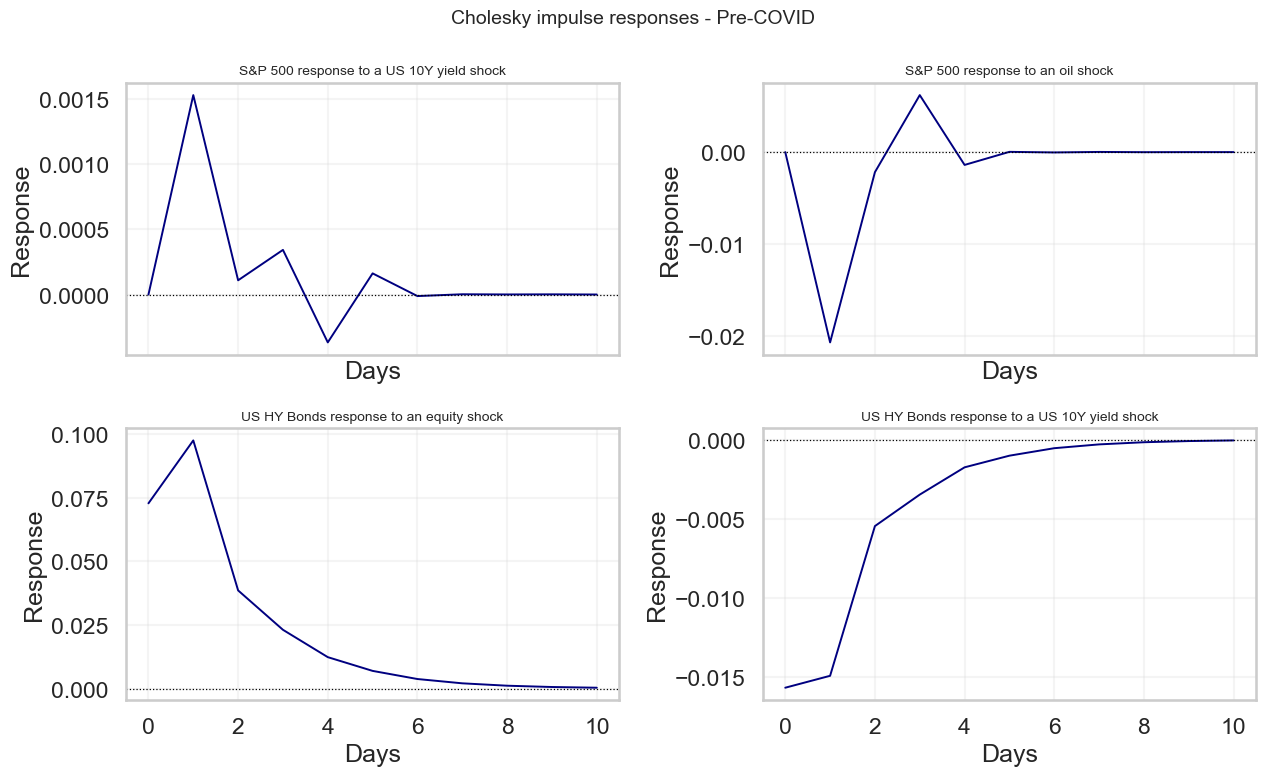

In [8]:
irf_pre_figure = plot_irf_panel(var_pre, "Pre-COVID")
save_figure(irf_pre_figure, "04_irf_pre_covid.png")
plt.show()

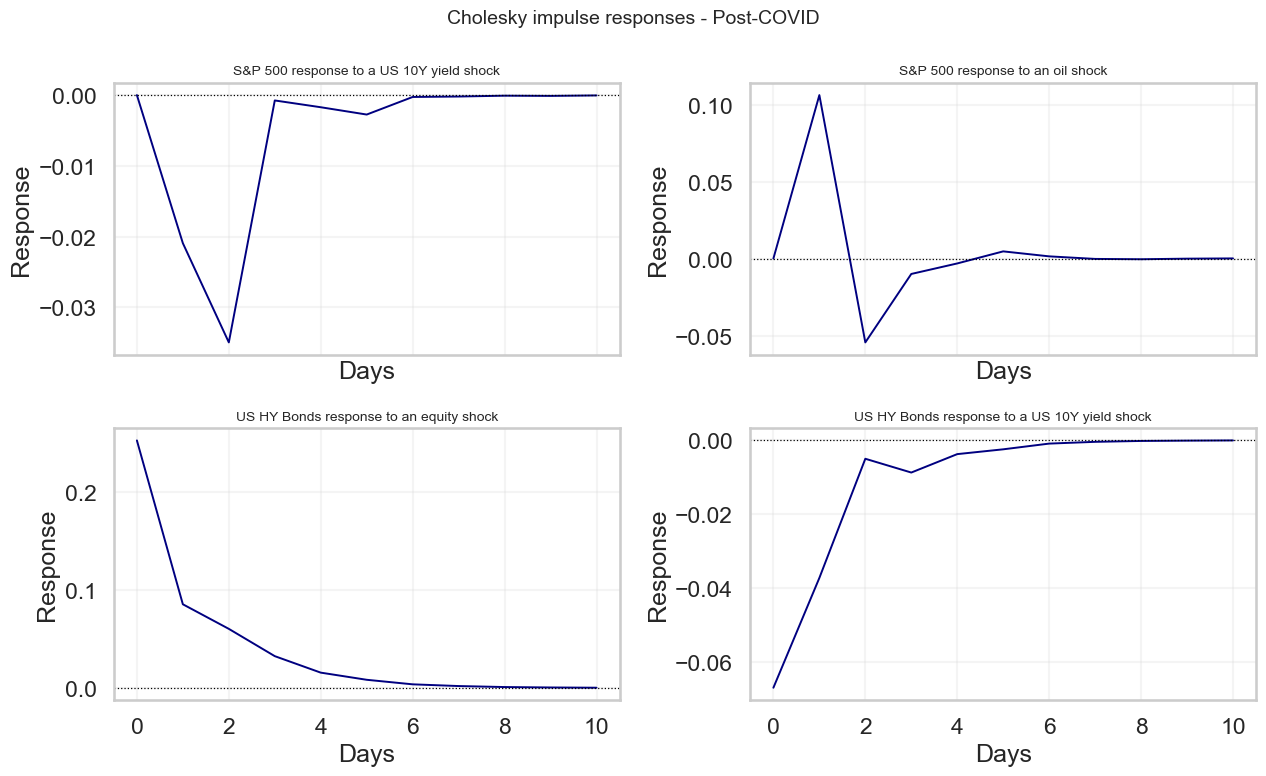

In [9]:
irf_post_figure = plot_irf_panel(var_post, "Post-COVID")
save_figure(irf_post_figure, "04_irf_post_covid.png")
plt.show()

## 7. Save the transmission outputs

We save the VAR summary, the Granger results and the Geweke tables so that the regime notebook can reuse the main transmission evidence without re-estimating everything manually.

In [10]:
save_var_outputs(var_summary, granger_results, geweke_results)
save_dataframe(var_order_table, "04_var_order_selection.csv")

## 8. Main takeaways from notebook 04

This notebook studies whether transmission channels changed after COVID-19. The Granger results indicate whether lagged spillovers became stronger or changed direction, the Geweke measures summarize directional and instantaneous dependence using a proper restricted-equation comparison, and the IRFs show whether shocks propagate differently through the system after the COVID break.